## Etapa 0 - Estabelecer o Dataset

- Entender como está estrutura o dataset, quais são as colunas, o que cada coluna representa
- Chegar a um requisito inicial de 200 mil palavras para a análise de palavras

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/damarals/biblias/main/inst/json/NVT.json'

dfb = pd.read_json(url)

dfb.head()
dfb_joao = dfb[dfb['name'] == 'João']
# Mostrar o DataFrame atualizado
dfb_joao.head()

# Para acessar capitulos
# joao_chapters = dfb_joao['chapters'].iloc[0]

,abbrev,chapters,name
42,Jo,"[[No princípio, aquele que é a Palavra já exis...",João


### Análise da Estrutura do Dataset - Livro de João

Verificar como os capítulos e versículos estão organizados no dataset.

In [2]:
# Extrair dados do livro de João
joao_data = dfb_joao.iloc[0]
joao_chapters = joao_data['chapters']

# 1. Informações gerais
print(f"\n1. INFORMAÇÕES GERAIS:")
print(f"   - Nome do livro: {joao_data['name']}")
print(f"   - Abreviação: {joao_data.get('abbrev', 'N/A')}")
print(f"   - Tipo de 'chapters': {type(joao_chapters)}")
print(f"   - Total de capítulos: {len(joao_chapters)}")

# 2. Criar DataFrame estruturado por capítulo
chapter_data = []
total_verses = 0

for chapter_num, chapter_verses in enumerate(joao_chapters, start=1):
    num_verses = len(chapter_verses)
    total_verses += num_verses

    # Contar palavras no capítulo
    chapter_words = sum(len(verse.split()) for verse in chapter_verses)

    # Pegar exemplo do primeiro versículo
    first_verse_preview = chapter_verses[0][:80] + "..." if len(chapter_verses[0]) > 80 else chapter_verses[0]

    chapter_data.append({
        'Capítulo': chapter_num,
        'Num_Versículos': num_verses,
        'Total_Palavras': chapter_words,
        'Primeiro_Versículo': first_verse_preview
    })

# Criar DataFrame
df_joao_structure = pd.DataFrame(chapter_data)

print(f"\n2. RESUMO ESTATÍSTICO:")
print(f"   - Total de versículos no livro: {total_verses}")
print(f"   - Total de palavras no livro: {df_joao_structure['Total_Palavras'].sum()}")
print(f"   - Média de versículos por capítulo: {df_joao_structure['Num_Versículos'].mean():.1f}")
print(f"   - Média de palavras por capítulo: {df_joao_structure['Total_Palavras'].mean():.1f}")

print(f"\n3. ESTRUTURA POR CAPÍTULO:")
display(df_joao_structure)

# 3. Exemplo detalhado de um capítulo específico (Capítulo 1)
print(f"\n4. EXEMPLO DETALHADO - CAPÍTULO 1:")
print(f"   - Número de versículos: {len(joao_chapters[0])}")
print(f"\n   Primeiros 5 versículos:")

for verse_num, verse_text in enumerate(joao_chapters[0][:5], start=1):
    print(f"   [{verse_num}] {verse_text}")

# 4. Verificar se há estrutura aninhada adicional
print(f"\n5. VERIFICAÇÃO DE ANINHAMENTO:")
sample_verse = joao_chapters[0][0]
print(f"   - Tipo do primeiro versículo: {type(sample_verse)}")
print(f"   - É uma string? {'✓ SIM' if isinstance(sample_verse, str) else '✗ NÃO (estrutura aninhada detectada)'}")

if isinstance(sample_verse, str):
    print(f"   - Estrutura confirmada: chapters[capítulo_idx][versículo_idx] = string")
else:
    print(f"   - ATENÇÃO: Estrutura mais complexa detectada!")
    print(f"   - Conteúdo do primeiro item: {sample_verse}")


1. INFORMAÇÕES GERAIS:
   - Nome do livro: João
   - Abreviação: Jo
   - Tipo de 'chapters': <class 'list'>
   - Total de capítulos: 21

2. RESUMO ESTATÍSTICO:
   - Total de versículos no livro: 879
   - Total de palavras no livro: 16840
   - Média de versículos por capítulo: 41.9
   - Média de palavras por capítulo: 801.9

3. ESTRUTURA POR CAPÍTULO:


,Capítulo,Num_Versículos,Total_Palavras,Primeiro_Versículo
0,1,51,918,"No princípio, aquele que é a Palavra já existi..."
1,2,25,461,"Três dias depois, houve uma festa de casamento..."
2,3,36,713,"Havia um fariseu chamado Nicodemos, líder reli..."
3,4,54,1027,Jesus sabia que os fariseus tinham ouvido dize...
4,5,47,928,"Depois disso, Jesus voltou a Jerusalém para um..."
5,6,71,1275,"Depois disso, Jesus atravessou o mar da Galile..."
6,7,53,955,"Depois disso, Jesus viajou pela Galileia. Quer..."
7,8,59,1172,"Jesus voltou ao monte das Oliveiras,"
8,9,41,749,"Enquanto caminhava, Jesus viu um homem cego de..."
9,10,42,735,“Eu lhes digo a verdade: quem entra no curral ...



4. EXEMPLO DETALHADO - CAPÍTULO 1:
   - Número de versículos: 51

   Primeiros 5 versículos:
   [1] No princípio, aquele que é a Palavra já existia. A Palavra estava com Deus, e a Palavra era Deus.
   [2] Ele existia no princípio com Deus.
   [3] Por meio dele Deus criou todas as coisas, e sem ele nada foi criado.
   [4] Aquele que é a Palavra possuía a vida, e sua vida trouxe luz a todos.
   [5] A luz brilha na escuridão, e a escuridão nunca conseguiu apagá-la.

5. VERIFICAÇÃO DE ANINHAMENTO:
   - Tipo do primeiro versículo: <class 'str'>
   - É uma string? ✓ SIM
   - Estrutura confirmada: chapters[capítulo_idx][versículo_idx] = string


In [3]:
import pandas as pd

dfb_full = dfb

# Define lists of books for the New Testament and Wisdom books (Old Testament)
new_testament_books = [
    'Mateus', 'Marcos', 'Lucas', 'João', 'Atos', 'Romanos', '1 Coríntios', '2 Coríntios',
    'Gálatas', 'Efésios', 'Filipenses', 'Colossenses', '1 Tessalonicenses', '2 Tessalonicenses',
    '1 Timóteo', '2 Timóteo', 'Tito', 'Filemom', 'Hebreus', 'Tiago', '1 Pedro', '2 Pedro',
    '1 João', '2 João', '3 João', 'Judas', 'Apocalipse'
]

wisdom_books_ot = [
    'Jó', 'Salmos', 'Provérbios', 'Eclesiastes', 'Cânticos'
]

# Combine the lists of desired books
selected_books = new_testament_books + wisdom_books_ot

# Filter the DataFrame for these selected books
dfb_selected = dfb_full[dfb_full['name'].isin(selected_books)].copy()

# Initialize total word count for all selected books
total_words_all_selected_books = 0

print(f"Starting word count for {len(selected_books)} selected books:\n")

# Iterate through each selected book to count words
for index, row in dfb_selected.iterrows():
    book_name = row['name']
    book_chapters_data = row['chapters'] # This could be a complex nested structure
    current_book_word_count = 0

    # Flatten book_chapters_data into a single list of all verse strings
    all_verses_for_book = []

    def flatten_list_of_lists(nested_list):
        for item in nested_list:
            if isinstance(item, list):
                yield from flatten_list_of_lists(item)
            else:
                yield item

    # Apply flattening. This handles arbitrary levels of nesting until strings are found.
    for verse_candidate in flatten_list_of_lists(book_chapters_data):
        if isinstance(verse_candidate, str):
            all_verses_for_book.append(verse_candidate)
        else:
            # This case indicates an unexpected non-string item after deep flattening
            print(f"Warning: Found non-string item in {book_name} after flattening: {verse_candidate} (type: {type(verse_candidate)}) - skipping")

    # Now, all_verses_for_book should be a flat list of strings
    for verse_text in all_verses_for_book:
        words = verse_text.split() # verse_text is guaranteed to be a string here
        current_book_word_count += len(words)

    print(f"  Book: {book_name} - Total words: {current_book_word_count}")
    total_words_all_selected_books += current_book_word_count

print(f"\n------------------------------------------------")
print(f"Total words across all selected books: {total_words_all_selected_books}")


Starting word count for 32 selected books:

  Book: Jó - Total words: 15419
  Book: Salmos - Total words: 36889
  Book: Provérbios - Total words: 13210
  Book: Eclesiastes - Total words: 4724
  Book: Cânticos - Total words: 2449
  Book: Mateus - Total words: 20990
  Book: Marcos - Total words: 13305
  Book: Lucas - Total words: 22346
  Book: João - Total words: 16840
  Book: Atos - Total words: 21569
  Book: Romanos - Total words: 9899
  Book: 1 Coríntios - Total words: 9364
  Book: 2 Coríntios - Total words: 6100
  Book: Gálatas - Total words: 3215
  Book: Efésios - Total words: 2992
  Book: Filipenses - Total words: 2197
  Book: Colossenses - Total words: 2045
  Book: 1 Tessalonicenses - Total words: 1801
  Book: 2 Tessalonicenses - Total words: 1018
  Book: 1 Timóteo - Total words: 2419
  Book: 2 Timóteo - Total words: 1748
  Book: Tito - Total words: 1042
  Book: Filemom - Total words: 430
  Book: Hebreus - Total words: 6792
  Book: Tiago - Total words: 2172
  Book: 1 Pedro - Total

## Etapa 1 - **Pré-processamento Textual**

Etapa para preparar o texto da Bíblia em português.

In [4]:
# 1. Instalação de dependências e download de modelos
!pip install -q spacy nltk pandas gensim scikit-learn wordcloud
!python -m spacy download pt_core_news_md

import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
import pandas as pd
import re
from collections import Counter
from typing import List, Dict, Any
import json
from pathlib import Path

# Downloads necessários para o NLTK
nltk.download('stopwords')
nltk.download('rslp')

print("\n[INFO] Ambiente configurado com sucesso.")
# O modelo 'pt_core_news_sm' é essencial para o spaCy processar a língua portuguesa,
# permitindo análise morfológica e lemmatização precisa, diferente de modelos em inglês
# que utilizam regras gramaticais e vocabulários distintos.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.0 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 17.9 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

[INFO] Ambiente configurado com sucesso.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


### Normalização de Clíticos

**Motivação**

O português possui alta variação morfológica e ortográfica em formas verbais e pronominais, por exemplo:

- flexão verbal
- composição com pronomes
- hifenização
- variações antigas da linguagem

Isso faz o vocabulário "explodir" artificialmente, prejudicando a qualidade de lematização e a consistência dos tópicos.

**Exemplos de variação encontradas no vocabulario**

- "ajoelhar se"
- "ajoelhar-se"
- "ajoelhavam-se"
- "ajoelhou se"
- "ajoelhou-se"
- "ajoelhour se"
- "ajuda nós"
- "ajuda-a"
- "ajuda-me"
- "ajuda-nos"
- "ajuda-o"
- "ajuda-os"

**Impacto esperado**

A normalização ocorre antes do spaCy, reduzindo variações superficiais e aumentando a chance de o lematizador convergir para a forma canônica. Isso tende a melhorar a densidade semântica e a estabilidade dos tópicos.

In [21]:
def normalize_clitics(text: str) -> str:
    """Remove pronomes encliticos comuns do portugues."""
    pattern = r'-(me|te|se|na|nas|no|nos|vos|lo|los|la|las|lhe|lhes|o|a|os|as)\b'
    return re.sub(pattern, '', text)


class BiblePreprocessor:
    """Classe para pre-processamento de texto biblico focado em Topic Modeling."""

    def __init__(self, custom_stopwords: List[str] = None):
        # Carregando spaCy pt_core_news_md para analise contextual
        self.nlp = spacy.load("pt_core_news_md")

        # Configuracao de Stopwords (NLTK + Custom)
        base_stopwords = set(stopwords.words('portuguese'))
        if custom_stopwords:
            base_stopwords.update(custom_stopwords)
        self.stop_words = base_stopwords

        self.stemmer = RSLPStemmer()  # Para comparacao academica
        
        # Dicionário de correções de lemmatização para termos religiosos
        # O modelo spaCy comete erros em alguns termos bíblicos específicos
        self.lemma_corrections = {
            'cristar': 'cristo',  # spaCy erroneamente lemmatiza "cristo" como "cristar"
            'agrar': 'agradar'
        }

    def clean_text(self, text: str) -> str:
        """Limpeza inicial: remocao de ruidos basicos."""
        text = text.lower()
        text = re.sub(r'\d+', '', text)  # Remove numeros
        text = re.sub(r'\s+', ' ', text).strip()  # Remove espacos extras
        return text

    def process_pipeline(self, text: str) -> List[str]:
        """
        Executa normalizacao de cliticos, Tokenizacao, Lematizacao e POS Filtering.
        Mantem apenas NOUN, VERB, ADJ para densidade semantica no Topic Modeling.
        """
        text = normalize_clitics(text)
        text = self.clean_text(text)
        doc = self.nlp(text)

        tokens_limpos = []
        for token in doc:
            # POS Filtering: Substantivos, Verbos e Adjetivos carregam o topico
            if token.pos_ in ['NOUN', 'VERB', 'ADJ']:
                # Lematizacao para reduzir dimensionalidade sem perder semantica
                lemma = token.lemma_
                
                # Aplicar correções customizadas de lemmatização
                lemma = self.lemma_corrections.get(lemma, lemma)
                
                if lemma not in self.stop_words and len(lemma) >= 2:
                    tokens_limpos.append(lemma)

        return tokens_limpos

In [ ]:
# Execução e Análise Quantitativa
custom_stops = ['capítulo', 'versículo', 'bíblia', 'livro']
preprocessor = BiblePreprocessor(custom_stopwords=custom_stops)

def get_book_text(chapters_data: Any) -> str:
    """Achata a estrutura de capítulos/versículos em uma única string."""
    def flatten(nested):
        for item in nested:
            if isinstance(item, list):
                yield from flatten(item)
            else:
                yield item
    return " ".join([str(v) for v in flatten(chapters_data)])

print(f"Processando {len(dfb_selected)} livros selecionados...")

corpus_final = []
for _, row in dfb_selected.iterrows():
    # Agrega todo o texto do livro de forma robusta
    full_text = get_book_text(row['chapters'])
    tokens = preprocessor.process_pipeline(full_text)
    corpus_final.append(tokens)

print(f"\n[INFO] Corpus processado. Total de documentos: {len(corpus_final)}")
print(f"Exemplo de tokens (primeiros 10 de {dfb_selected['name'].iloc[0]}):", corpus_final[0][:10])

Processando 32 livros selecionados...

[INFO] Corpus processado. Total de documentos: 32
Exemplo de tokens (primeiros 10 de Jó): ['homem', 'chamar', 'viver', 'terra', 'íntegro', 'correto', 'temer', 'deus', 'manter', 'afastar']


In [23]:
# Análise Quantitativa e Métricas de Impacto

def calculate_metrics(tokens_list: List[str]) -> Dict[str, Any]:
    """Calcula métricas básicas de NLP para análise de densidade lexical."""
    total_tokens = len(tokens_list)
    vocab_size = len(set(tokens_list))
    ttr = vocab_size / total_tokens if total_tokens > 0 else 0
    return {
        "total_tokens": total_tokens,
        "vocab_size": vocab_size,
        "ttr": round(ttr, 4)
    }

# Analisando o impacto (Exemplo com o primeiro livro)
first_book_name = dfb_selected['name'].iloc[0]
raw_text_example = get_book_text(dfb_selected['chapters'].iloc[0])
raw_tokens = raw_text_example.split()

metrics_raw = calculate_metrics(raw_tokens)
metrics_processed = calculate_metrics(corpus_final[0])

# Criando tabela comparativa de impacto
df_impacto = pd.DataFrame({
    "Métrica": ["Total de Tokens", "Tamanho do Vocabulário", "Type-Token Ratio (TTR)"],
    "Original": [metrics_raw['total_tokens'], metrics_raw['vocab_size'], metrics_raw['ttr']],
    "Pós-Processamento": [metrics_processed['total_tokens'], metrics_processed['vocab_size'], metrics_processed['ttr']]
})

print(f"\n[ANÁLISE] Impacto do Pré-processamento no livro: {first_book_name}")
display(df_impacto)

# Justificativa Técnica:
# A redução no tamanho do vocabulário e o ajuste do TTR são fundamentais para LDA/NMF.
# Menos 'ruído' (tokens irrelevantes) permite que o modelo foque em padrões probabilísticos
# de palavras que realmente definem o conteúdo semântico dos tópicos."

# 4. Geração do Corpus Final e Persistência

# Preparando listas para Topic Modeling (Gensim e Sklearn)
# corpus_final já é uma lista de listas de tokens

# Exportação para JSON (Vocabulário)
all_tokens_flat = [t for doc in corpus_final for t in doc]
vocabulario = sorted(list(set(all_tokens_flat)))

output_path = Path("preprocessed_bible")
output_path.mkdir(exist_ok=True)

with open(output_path / "vocabulario.json", "w", encoding="utf-8") as f:
    json.dump(vocabulario, f, ensure_ascii=False, indent=4)

# Salvando corpus preprocessado
with open(output_path / "corpus_final.txt", "w", encoding="utf-8") as f:
    for doc_tokens in corpus_final:
        f.write(" ".join(doc_tokens) + "\n")

print(f"\nPipeline finalizado.")
print(f"- Arquivos salvos em: {output_path}/")
print(f"- Vocabulário final: {len(vocabulario)} termos únicos.")



[ANÁLISE] Impacto do Pré-processamento no livro: Jó


,Métrica,Original,Pós-Processamento
0,Total de Tokens,15419.0000,6714.0000
1,Tamanho do Vocabulário,4836.0000,2101.0000
2,Type-Token Ratio (TTR),0.3136,0.3129



Pipeline finalizado.
- Arquivos salvos em: preprocessed_bible/
- Vocabulário final: 7824 termos únicos.


### Resultado Visual da Etapa 1: WordCloud

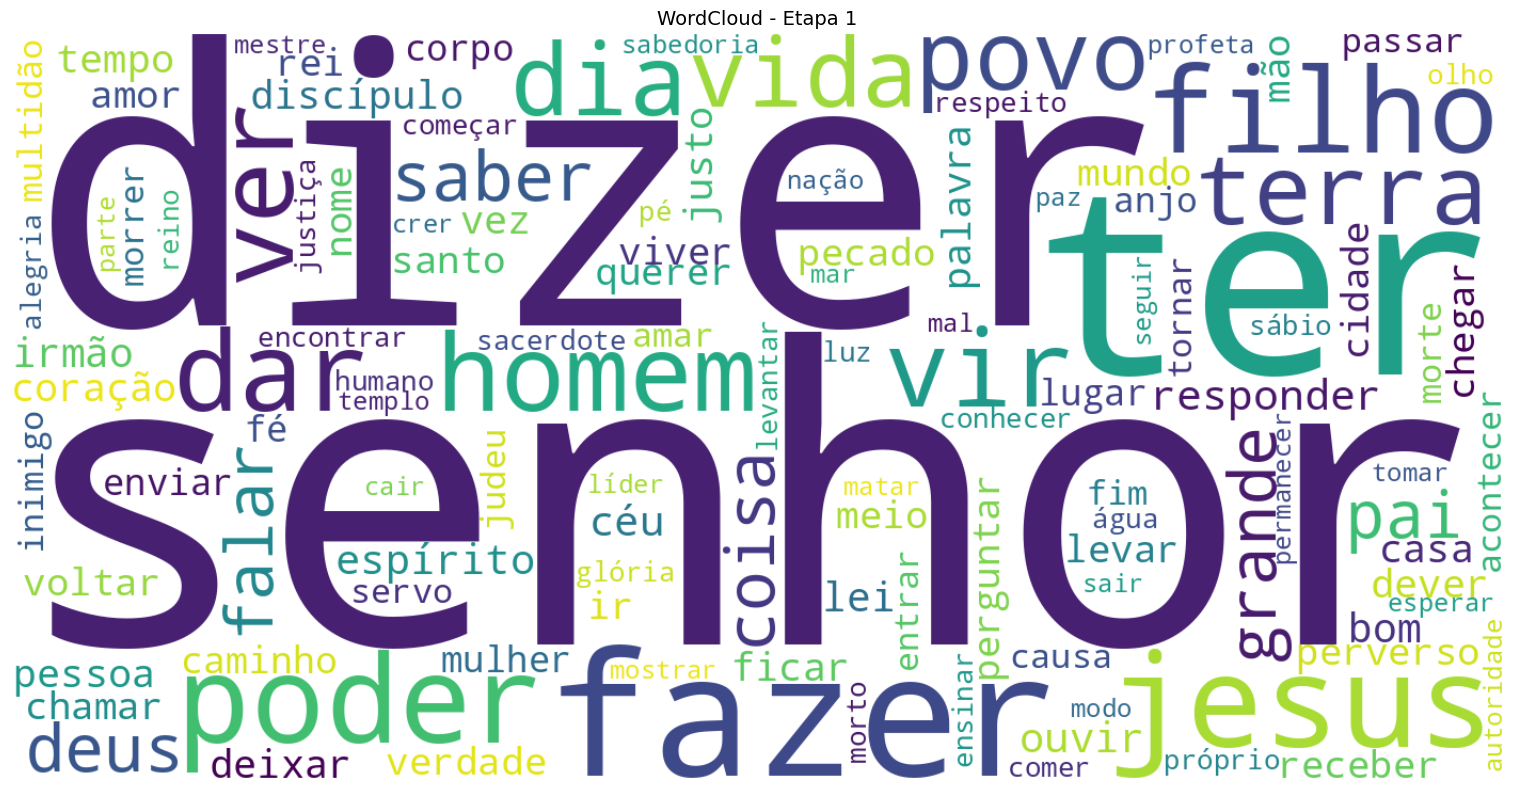

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# Garante que o corpus possui dados antes de gerar a visualização
if not all_tokens_flat:
    raise ValueError("all_tokens_flat está vazio. Execute a etapa de pré-processamento antes da WordCloud.")

# Frequências a partir do corpus já preprocessado
frequencias = Counter(all_tokens_flat)

# Geração da WordCloud
wc = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=120,
    collocations=False,
    random_state=42
).generate_from_frequencies(frequencias)

# Exibição
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title(
    f"WordCloud - Etapa 1",
    fontsize=14
)
plt.tight_layout()
plt.show()

# Persistência em arquivo
output_dir = Path("preprocessed_bible")
output_dir.mkdir(exist_ok=True)
output_file = output_dir / "wordcloud_etapa1.png"
wc.to_file(str(output_file))

## Distribuição de termos frequentes


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Análise de frequência por livro
print("=" * 80)
print("ANÁLISE DE DISTRIBUIÇÃO DE FREQUÊNCIAS POR LIVRO")
print("=" * 80)

# Dicionário para armazenar estatísticas por livro
book_statistics = {}

for book_idx, (book_name, tokens) in enumerate(zip(dfb_selected['name'], corpus_final)):
    freq_counter = Counter(tokens)
    freq_values = list(freq_counter.values())

    # Calcular estatísticas
    stats = {
        'total_tokens': len(tokens),
        'unique_terms': len(freq_counter),
        'mean_freq': np.mean(freq_values),
        'median_freq': np.median(freq_values),
        'std_freq': np.std(freq_values),
        'min_freq': np.min(freq_values),
        'max_freq': np.max(freq_values),
        'ttr': len(freq_counter) / len(tokens) if len(tokens) > 0 else 0
    }

    book_statistics[book_name] = stats

# Tabela comparativa de todos os livros
df_books_stats = pd.DataFrame(book_statistics).T
df_books_stats = df_books_stats.round(2)

print("\n[TABELA] Estatísticas de Frequência por Livro:\n")
display(df_books_stats)

# Análise de Variação: Comparação entre Livros
print("\n[COMPARAÇÃO] Top 10 Livros por Número de Tokens Únicos:")
top_books_unique = df_books_stats.nlargest(10, 'unique_terms')[['total_tokens', 'unique_terms', 'ttr']]
display(top_books_unique)

print("\n[COMPARAÇÃO] Top 10 Livros por Type-Token Ratio (Diversidade Lexical):")
top_books_ttr = df_books_stats.nlargest(10, 'ttr')[['total_tokens', 'unique_terms', 'ttr']]
display(top_books_ttr)

ANÁLISE DE DISTRIBUIÇÃO DE FREQUÊNCIAS POR LIVRO

[TABELA] Estatísticas de Frequência por Livro:



,total_tokens,unique_terms,mean_freq,median_freq,std_freq,min_freq,max_freq,ttr
Jó,6666.0,2092.0,3.19,1.0,6.06,1.0,103.0,0.31
Salmos,15787.0,2998.0,5.27,2.0,18.65,1.0,810.0,0.19
Provérbios,6290.0,1781.0,3.53,1.0,7.38,1.0,106.0,0.28
Eclesiastes,2007.0,811.0,2.47,1.0,4.51,1.0,63.0,0.40
Cânticos,1060.0,538.0,1.97,1.0,2.34,1.0,31.0,0.51
Mateus,8853.0,1952.0,4.54,2.0,11.12,1.0,267.0,0.22
Marcos,5584.0,1462.0,3.82,1.0,8.75,1.0,171.0,0.26
Lucas,9328.0,2084.0,4.48,2.0,12.27,1.0,301.0,0.22
João,6464.0,1294.0,5.00,2.0,14.04,1.0,314.0,0.20
Atos,8952.0,1980.0,4.52,2.0,9.88,1.0,173.0,0.22



[COMPARAÇÃO] Top 10 Livros por Número de Tokens Únicos:


,total_tokens,unique_terms,ttr
Salmos,15787.0,2998.0,0.19
Jó,6666.0,2092.0,0.31
Lucas,9328.0,2084.0,0.22
Atos,8952.0,1980.0,0.22
Mateus,8853.0,1952.0,0.22
Provérbios,6290.0,1781.0,0.28
Marcos,5584.0,1462.0,0.26
João,6464.0,1294.0,0.20
Romanos,3790.0,1157.0,0.31
Apocalipse,4442.0,1136.0,0.26



[COMPARAÇÃO] Top 10 Livros por Type-Token Ratio (Diversidade Lexical):


,total_tokens,unique_terms,ttr
3 João,120.0,91.0,0.76
Judas,291.0,221.0,0.76
Filemom,161.0,116.0,0.72
2 João,112.0,80.0,0.71
2 Timóteo,706.0,445.0,0.63
Tito,456.0,281.0,0.62
2 Tessalonicenses,381.0,224.0,0.59
2 Pedro,621.0,366.0,0.59
Tiago,921.0,537.0,0.58
Filipenses,821.0,455.0,0.55


## Etapa 2 - **Representação vetorial e busca textual**
- TF-IDF com TfidfVectorizer
- Word2Vec com Gensim

| Aspecto | TF-IDF | Word2Vec |
|---------|--------|----------|
| **Representação** | Esparsa (99%+ zeros) | Densa (todos valores preenchidos) |
| **Dimensionalidade** | ~5000 features | 100 dimensões |
| **Captura** | Frequência estatística | Relações semânticas |
| **Melhor para** | Termos raros, palavras-chave específicas | Sinônimos, conceitos relacionados |
| **Limitação** | Ignora semântica (não sabe que "amar" ≈ "afeição") | Ignora frequência estatística (trata "o" como "ressurreição") |
| **Velocidade** | Rápido (sparse matrix operations) | Moderado (requer cálculo de média de embeddings) |


In [10]:
# Instalar gensim para Word2Vec (sklearn já foi instalado na Etapa 1)
!pip install -q gensim

import numpy as np
import pandas as pd
from typing import List, Tuple, Optional
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore')

print("[INFO] Bibliotecas carregadas com sucesso.")
print(f"[INFO] Corpus disponível: {len(corpus_final)} livros")
print(f"[INFO] Nome dos livros: {list(dfb_selected['name'])}")

[INFO] Bibliotecas carregadas com sucesso.
[INFO] Corpus disponível: 32 livros
[INFO] Nome dos livros: ['Jó', 'Salmos', 'Provérbios', 'Eclesiastes', 'Cânticos', 'Mateus', 'Marcos', 'Lucas', 'João', 'Atos', 'Romanos', '1 Coríntios', '2 Coríntios', 'Gálatas', 'Efésios', 'Filipenses', 'Colossenses', '1 Tessalonicenses', '2 Tessalonicenses', '1 Timóteo', '2 Timóteo', 'Tito', 'Filemom', 'Hebreus', 'Tiago', '1 Pedro', '2 Pedro', '1 João', '2 João', '3 João', 'Judas', 'Apocalipse']


In [26]:
# ============================================================================
# IMPLEMENTAÇÃO TF-IDF
# ============================================================================

# Preparar corpus: juntar tokens de cada documento em uma única string
# TfidfVectorizer espera uma lista de strings (uma por documento)
corpus_strings = [" ".join(tokens) for tokens in corpus_final]

# Configurar TF-IDF Vectorizer
# max_features=None: sem limitação de vocabulário
# Corpus pequeno permite usar todos os ~7824 termos após preprocessing
# sem problemas de performance. Preserva termos bíblicos específicos importantes.
tfidf_vectorizer = TfidfVectorizer(
    max_features=None,        
    ngram_range=(1, 2),       # Captura unigramas e bigramas (ex: "espírito santo")
    min_df=2,                 # Termo deve aparecer em pelo menos 2 documentos
    max_df=0.8,               # Remove termos que aparecem em mais de 80% dos docs
    lowercase=True,           # Normalização (já feita no preprocessing, mas garantimos)
    token_pattern=r'(?u)\b\w+\b'  # Padrão de tokenização básico
)

# Ajustar o vectorizer ao corpus e transformar em matriz TF-IDF
print("[INFO] Treinando TF-IDF Vectorizer...")
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_strings)

print(f"[RESULTADO] Matriz TF-IDF criada:")
print(f"  - Shape: {tfidf_matrix.shape} (documentos X features)")
print(f"  - Número de documentos: {tfidf_matrix.shape[0]}")
print(f"  - Tamanho do vocabulário: {tfidf_matrix.shape[1]}")
print(f"  - Densidade da matriz: {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}")
print(f"    (Representação esparsa: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}% zeros)")

# Exemplos de termos capturados
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n[VOCABULÁRIO] Exemplos de termos (unigramas e bigramas):")
print(f"  - Primeiros 10: {list(feature_names[:10])}")
print(f"  - Últimos 10: {list(feature_names[-10:])}")

# Procurar por bigramas religiosos no vocabulário
# Nota: Os bigramas contêm tokens LEMMATIZADOS do pré-processamento
# Isso é esperado: TF-IDF opera sobre o corpus já preprocessado (lemmatizado)
religious_bigrams = [term for term in feature_names if ' ' in term and any(keyword in term for keyword in ['santo', 'jesus', 'deus', 'senhor', 'espírito', 'cristo'])]
print(f"\n[BIGRAMAS RELIGIOSOS] Exemplos capturados (formas lemmatizadas): {religious_bigrams[:15]}")

[INFO] Treinando TF-IDF Vectorizer...
[RESULTADO] Matriz TF-IDF criada:
  - Shape: (32, 13894) (documentos X features)
  - Número de documentos: 32
  - Tamanho do vocabulário: 13894
  - Densidade da matriz: 0.1111
    (Representação esparsa: 88.89% zeros)

[VOCABULÁRIO] Exemplos de termos (unigramas e bigramas):
  - Primeiros 10: ['aba', 'aba pai', 'abaixar', 'abaixar olhar', 'abalado', 'abalado direita', 'abalar', 'abalar ver', 'abandonar', 'abandonar escritura']
  - Últimos 10: ['único', 'único coisa', 'único deus', 'único esperança', 'único filho', 'único homem', 'único pessoa', 'único recompensa', 'único sinal', 'útil']

[BIGRAMAS RELIGIOSOS] Exemplos capturados (formas lemmatizadas): ['abandonar jesus', 'abrir espírito', 'acaso senhor', 'acontecer senhor', 'adorar deus', 'adorar jesus', 'adorar senhor', 'afirmar espírito', 'agarrar jesus', 'agradam deus', 'agradar deus', 'agradar senhor', 'agradecer deus', 'agradeçar deus', 'ajoelhar jesus']


In [27]:
# ============================================================================
# FUNÇÃO DE BUSCA TF-IDF
# ============================================================================

def search_tfidf(query: str, top_k: int = 5) -> List[Tuple[str, float]]:
    """
    Busca documentos mais similares usando TF-IDF e similaridade cosseno.
    
    Args:
        query: Consulta textual do usuário
        top_k: Número de documentos mais similares a retornar
    
    Returns:
        Lista de tuplas (nome_do_livro, score_similaridade) ordenada por relevância
    
    Funcionamento:
        1. Preprocessa a consulta usando o mesmo pipeline do corpus
        2. Transforma a consulta em vetor TF-IDF
        3. Calcula similaridade cosseno com todos os documentos
        4. Retorna os Top-K documentos ordenados por score
    """
    # 1. Preprocessar query com o mesmo pipeline da Etapa 1
    #    Isso garante consistência: mesma tokenização, lemmatização, stopwords
    query_tokens = preprocessor.process_pipeline(query)
    
    if not query_tokens:
        print("[AVISO] Query vazia após preprocessing. Retornando lista vazia.")
        return []
    
    # Juntar tokens preprocessados em string
    query_processed = " ".join(query_tokens)
    
    # 2. Transformar query em vetor TF-IDF usando vocabulário treinado
    #    transform() usa o vocabulário já aprendido (não reajusta IDF)
    query_vector = tfidf_vectorizer.transform([query_processed])
    
    # 3. Calcular similaridade cosseno entre query e todos os documentos
    #    Resultado: array de shape (1, n_documentos) com scores [0, 1]
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    # 4. Ordenar documentos por similaridade (decrescente) e pegar Top-K
    #    argsort() retorna índices ordenados; [::-1] inverte para ordem decrescente
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    # 5. Construir lista de resultados com (nome_livro, score)
    book_names = dfb_selected['name'].tolist()
    results = [(book_names[idx], similarities[idx]) for idx in top_indices]
    
    return results


# Teste da função com uma consulta exemplo
print("=" * 80)
print("TESTE DA BUSCA TF-IDF")
print("=" * 80)

test_query = "ressurreição de jesus cristo"
print(f"\n[CONSULTA] '{test_query}'")
print(f"[PREPROCESSADA] {' '.join(preprocessor.process_pipeline(test_query))}")

results = search_tfidf(test_query, top_k=5)

print(f"\n[RESULTADOS] Top-5 livros mais similares:\n")
for rank, (book_name, score) in enumerate(results, start=1):
    print(f"  {rank}. {book_name:20s} | Score: {score:.4f}")

print("\n" + "=" * 80)

TESTE DA BUSCA TF-IDF

[CONSULTA] 'ressurreição de jesus cristo'
[PREPROCESSADA] ressurreição jesus cristo

[RESULTADOS] Top-5 livros mais similares:

  1. 1 Pedro              | Score: 0.1351
  2. Filipenses           | Score: 0.1345
  3. Marcos               | Score: 0.1106
  4. Lucas                | Score: 0.1076
  5. João                 | Score: 0.1003



### Busca Semântica com Word2Vec

**Word2Vec** é uma técnica de aprendizado não supervisionado que aprende representações vetoriais densas (embeddings) para palavras, capturando relações semânticas através do contexto distribucional.

**Diferença fundamental de TF-IDF**:
- **TF-IDF**: Representação esparsa baseada em estatísticas de frequência (não captura semântica)
- **Word2Vec**: Representação densa baseada em contexto (captura relações semânticas)
  - Palavras com contextos similares ficam próximas no espaço vetorial
  - Ex: "rei" - "homem" + "mulher" ≈ "rainha"

**Arquiteturas disponíveis**:
1. **CBOW (Continuous Bag-of-Words)**: Prevê palavra central dado o contexto
   - Mais rápido, melhor para corpus grandes, favorece palavras frequentes
2. **Skip-gram**: Prevê contexto dada a palavra central  
   - Mais lento, melhor para corpus pequenos, melhor para palavras raras

**Importante**: Cada documento será representado pela **média dos embeddings** de suas palavras.
- **Limitação**: Perde ordem das palavras e nuances sintáticas
- **Vantagem**: Captura o "tema geral" do documento através do vocabulário semântico

### Parâmetros iniciais que não tiveram um resultado satisfatório

```
w2v_model = Word2Vec(
    sentences=corpus_final,      # Corpus tokenizado
    vector_size=100,             # Dimensionalidade dos embeddings
    window=5,                    # Janela de contexto (5 palavras antes e depois)
    min_count=3,                 # Ignora palavras com frequência < 3
    sg=1,                        # Skip-gram (1) ao invés de CBOW (0)
    epochs=20,                   # Número de iterações sobre o corpus
    workers=4,                   # Paralelização
    seed=42                      # Reprodutibilidade
)
```

### Resultado inicial 

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'jesus':
  - natanael        | Similaridade: 0.6854
  - levita          | Similaridade: 0.6611 
  - rabi            | Similaridade: 0.6445
  - surpreso        | Similaridade: 0.6332
  - dizer           | Similaridade: 0.6324
  - apelidar        | Similaridade: 0.6195 
  - enviarei        | Similaridade: 0.6184
  - repreendir      | Similaridade: 0.6175
  - legião          | Similaridade: 0.6168
  - criada          | Similaridade: 0.6165

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'fé':
  - Unidos          | Similaridade: 0.5816
  - declarados      | Similaridade: 0.5758
  - sirvo           | Similaridade: 0.5580
  - comentar        | Similaridade: 0.5558
  - lembrá          | Similaridade: 0.5548

In [ ]:
# ============================================================================
# TREINAMENTO WORD2VEC
# ============================================================================

print("[INFO] Treinando modelo Word2Vec...")
print(f"  - Corpus: {len(corpus_final)} documentos")
print(f"  - Total de tokens: {sum(len(doc) for doc in corpus_final)}")

# Treinar Word2Vec com arquitetura Skip-gram
# Entrada: lista de listas de tokens (corpus_final já está nesse formato)



w2v_model = Word2Vec(
    sentences=corpus_final,
    vector_size=180,          # ↑ de 100
    window=12,                # ↑ de 5
    min_count=2,              # ↓ de 3
    sg=1,                     # Mantém Skip-gram (bom para corpus pequenos)
    epochs=60,                # ↑ de 20
    negative=15,              # Novo parâmetro
    ns_exponent=0.75,         # Novo parâmetro
    alpha=0.025,              # Novo parâmetro (padrão, mas explícito)
    min_alpha=0.0001,         # Taxa de aprendizado final
    workers=4,
    seed=42
)

print(f"\n[RESULTADO] Modelo Word2Vec treinado:")
print(f"  - Vocabulário: {len(w2v_model.wv)} palavras")
print(f"  - Dimensionalidade: {w2v_model.wv.vector_size}")
print(f"  - Arquitetura: Skip-gram")

# Verificar qualidade semântica: palavras similares a "jesus"
print(f"\n[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'jesus':")
try:
    similar_words = w2v_model.wv.most_similar('jesus', topn=10)
    for word, similarity in similar_words:
        print(f"  - {word:15s} | Similaridade: {similarity:.4f}")
except KeyError:
    print("  [ERRO] Palavra 'jesus' não encontrada no vocabulário.")

# Testar outras palavras-chave
print(f"\n[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'fé':")
try:
    similar_faith = w2v_model.wv.most_similar('fé', topn=10)
    for word, similarity in similar_faith:
        print(f"  - {word:15s} | Similaridade: {similarity:.4f}")
except KeyError:
    print("  [ERRO] Palavra 'fé' não encontrada no vocabulário.")

[INFO] Treinando modelo Word2Vec...
  - Corpus: 32 documentos
  - Total de tokens: 100077

[RESULTADO] Modelo Word2Vec treinado:
  - Vocabulário: 4744 palavras
  - Dimensionalidade: 180
  - Arquitetura: Skip-gram

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'jesus':
  - dizer           | Similaridade: 0.7120
  - perguntar       | Similaridade: 0.6262
  - homem           | Similaridade: 0.6113
  - discípulo       | Similaridade: 0.6035
  - mestre          | Similaridade: 0.5156
  - responder       | Similaridade: 0.5081
  - senhor          | Similaridade: 0.5037
  - multidão        | Similaridade: 0.4858
  - vir             | Similaridade: 0.4828
  - fariseu         | Similaridade: 0.4700

[VALIDAÇÃO SEMÂNTICA] Palavras mais similares a 'fé':
  - vacilar         | Similaridade: 0.4329
  - justa           | Similaridade: 0.4277
  - prometer        | Similaridade: 0.4219
  - raabe           | Similaridade: 0.4052
  - perseverança    | Similaridade: 0.3913
  - poder           | Similar

In [31]:
# ============================================================================
# EMBEDDINGS DE DOCUMENTOS (MÉDIA DOS WORD EMBEDDINGS)
# ============================================================================

def document_vector(tokens: List[str], model: Word2Vec) -> Optional[np.ndarray]:
    """
    Calcula o embedding de um documento como a média dos embeddings de suas palavras.
    
    Args:
        tokens: Lista de tokens do documento
        model: Modelo Word2Vec treinado
    
    Returns:
        Vetor numpy de dimensão (vector_size,) ou None se nenhuma palavra estiver no vocabulário
    
    Por que média de embeddings pode representar documentos?
        - Cada palavra contribui com seu significado semântico
        - A média captura o "tema central" do documento
        - Palavras semanticamente relacionadas reforçam direções comuns no espaço vetorial
    
    Limitações da média:
        - Perde ordem das palavras (bag-of-words semântico)
        - Dá peso igual a todas as palavras (não considera importância TF-IDF)
        - Palavras OOV (Out-Of-Vocabulary) são ignoradas
        - Pode haver cancelamento de vetores opostos (ex: "bom" e "ruim")
    """
    # Filtrar apenas tokens que existem no vocabulário do Word2Vec
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    
    if len(vectors) == 0:
        # Nenhuma palavra da query está no vocabulário
        return None
    
    # Calcular média dos vetores (axis=0 para média por coluna)
    return np.mean(vectors, axis=0)


# Pré-computar embeddings de todos os documentos do corpus
# Isso evita recalcular a cada busca (otimização de performance)
print("[INFO] Computando embeddings médios para todos os documentos...")

doc_embeddings = []
doc_embeddings_valid_indices = []  # Índices de documentos com embeddings válidos

for idx, doc_tokens in enumerate(corpus_final):
    doc_vec = document_vector(doc_tokens, w2v_model)
    if doc_vec is not None:
        doc_embeddings.append(doc_vec)
        doc_embeddings_valid_indices.append(idx)
    else:
        # Documento não tem nenhuma palavra no vocabulário (improvável, mas possível)
        print(f"  [AVISO] Documento {idx} ({dfb_selected['name'].iloc[idx]}) sem palavras no vocabulário W2V")

# Converter lista de vetores em matriz numpy (n_docs, vector_size)
doc_embeddings_matrix = np.array(doc_embeddings)

print(f"\n[RESULTADO] Embeddings de documentos computados:")
print(f"  - Total de documentos: {len(corpus_final)}")
print(f"  - Documentos com embeddings válidos: {len(doc_embeddings)}")
print(f"  - Shape da matriz: {doc_embeddings_matrix.shape} (documentos x dimensão)")

# Verificar se algum documento ficou sem embedding
if len(doc_embeddings) < len(corpus_final):
    print(f"  [ATENÇÃO] {len(corpus_final) - len(doc_embeddings)} documento(s) sem embedding (todas palavras OOV)")

[INFO] Computando embeddings médios para todos os documentos...

[RESULTADO] Embeddings de documentos computados:
  - Total de documentos: 32
  - Documentos com embeddings válidos: 32
  - Shape da matriz: (32, 180) (documentos x dimensão)


In [32]:
# ============================================================================
# FUNÇÃO DE BUSCA WORD2VEC
# ============================================================================

def search_word2vec(query: str, top_k: int = 5) -> List[Tuple[str, float]]:
    """
    Busca documentos mais similares usando Word2Vec e similaridade cosseno.
    
    Args:
        query: Consulta textual do usuário
        top_k: Número de documentos mais similares a retornar
    
    Returns:
        Lista de tuplas (nome_do_livro, score_similaridade) ordenada por relevância
    
    Funcionamento:
        1. Preprocessa a consulta usando o mesmo pipeline do corpus
        2. Calcula embedding médio da consulta
        3. Calcula similaridade cosseno com embeddings dos documentos
        4. Retorna os Top-K documentos ordenados por score
    """
    # 1. Preprocessar query
    query_tokens = preprocessor.process_pipeline(query)
    
    if not query_tokens:
        print("[AVISO] Query vazia após preprocessing. Retornando lista vazia.")
        return []
    
    # 2. Calcular embedding médio da query
    query_vector = document_vector(query_tokens, w2v_model)
    
    if query_vector is None:
        print("[AVISO] Nenhuma palavra da query está no vocabulário Word2Vec. Retornando lista vazia.")
        print(f"  Query tokens: {query_tokens}")
        return []
    
    # 3. Calcular similaridade cosseno com todos os documentos
    #    Reshape query_vector para (1, vector_size) para cosine_similarity
    query_vector_reshaped = query_vector.reshape(1, -1)
    similarities = cosine_similarity(query_vector_reshaped, doc_embeddings_matrix).flatten()
    
    # 4. Ordenar documentos por similaridade (decrescente) e pegar Top-K
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    # 5. Mapear índices para nomes de livros (considerando documentos válidos)
    book_names = dfb_selected['name'].tolist()
    results = [
        (book_names[doc_embeddings_valid_indices[idx]], similarities[idx])
        for idx in top_indices
    ]
    
    return results


# Teste da função com a mesma consulta do TF-IDF
print("=" * 80)
print("TESTE DA BUSCA WORD2VEC")
print("=" * 80)

test_query_w2v = "ressurreição de jesus cristo"
print(f"\n[CONSULTA] '{test_query_w2v}'")
print(f"[PREPROCESSADA] {' '.join(preprocessor.process_pipeline(test_query_w2v))}")

results_w2v = search_word2vec(test_query_w2v, top_k=5)

print(f"\n[RESULTADOS] Top-5 livros mais similares:\n")
for rank, (book_name, score) in enumerate(results_w2v, start=1):
    print(f"  {rank}. {book_name:20s} | Score: {score:.4f}")

print("\n" + "=" * 80)

TESTE DA BUSCA WORD2VEC

[CONSULTA] 'ressurreição de jesus cristo'
[PREPROCESSADA] ressurreição jesus cristo

[RESULTADOS] Top-5 livros mais similares:

  1. Gálatas              | Score: 0.6451
  2. Romanos              | Score: 0.6446
  3. 1 Coríntios          | Score: 0.6392
  4. João                 | Score: 0.6377
  5. Colossenses          | Score: 0.6375



In [ ]:
# ============================================================================
# FUNÇÃO DE COMPARAÇÃO ENTRE MÉTODOS
# ============================================================================

def compare_methods(query: str, top_k: int = 5) -> None:
    """
    Compara resultados de busca entre TF-IDF e Word2Vec lado a lado.
    
    Args:
        query: Consulta textual do usuário
        top_k: Número de documentos mais similares a retornar por método
    """
    print("=" * 100)
    print(f"COMPARAÇÃO DE MÉTODOS: TF-IDF vs Word2Vec")
    print("=" * 100)
    print(f"\n[CONSULTA] '{query}'")
    print(f"[PREPROCESSADA] {' '.join(preprocessor.process_pipeline(query))}\n")
    
    # Buscar com ambos os métodos
    results_tfidf = search_tfidf(query, top_k=top_k)
    results_w2v = search_word2vec(query, top_k=top_k)
    
    # Exibir resultados lado a lado
    print(f"{'TF-IDF (Correspondência Lexical)':<50} | {'Word2Vec (Similaridade Semântica)':<50}")
    print("-" * 100)
    
    for i in range(max(len(results_tfidf), len(results_w2v))):
        # TF-IDF
        if i < len(results_tfidf):
            book_tfidf, score_tfidf = results_tfidf[i]
            tfidf_str = f"{i+1}. {book_tfidf[:25]:25s} ({score_tfidf:.4f})"
        else:
            tfidf_str = ""
        
        # Word2Vec
        if i < len(results_w2v):
            book_w2v, score_w2v = results_w2v[i]
            w2v_str = f"{i+1}. {book_w2v[:25]:25s} ({score_w2v:.4f})"
        else:
            w2v_str = ""
        
        print(f"{tfidf_str:<50} | {w2v_str:<50}")
    
    print("=" * 100)
    
    # Análise de interseção
    books_tfidf = {book for book, _ in results_tfidf}
    books_w2v = {book for book, _ in results_w2v}
    intersection = books_tfidf & books_w2v
    
    print(f"\n[ANÁLISE]")
    print(f"  - Livros em comum (ambos os métodos): {len(intersection)}")
    if intersection:
        print(f"    → {', '.join(intersection)}")
    print(f"  - Apenas TF-IDF: {len(books_tfidf - books_w2v)}")
    if books_tfidf - books_w2v:
        print(f"    → {', '.join(books_tfidf - books_w2v)}")
    print(f"  - Apenas Word2Vec: {len(books_w2v - books_tfidf)}")
    if books_w2v - books_tfidf:
        print(f"    → {', '.join(books_w2v - books_tfidf)}")
    print()


# Testar com queries variadas para demonstrar diferenças
test_queries = [
    "fé e salvação",
    "mulher e o dragão", 
    "milagres de jesus"
]

for query in test_queries:
    compare_methods(query, top_k=5)
    print("\n")

COMPARAÇÃO DE MÉTODOS: TF-IDF vs Word2Vec

[CONSULTA] 'fé e salvação'
[PREPROCESSADA] salvação

TF-IDF (Correspondência Lexical)                   | Word2Vec (Similaridade Semântica)                 
----------------------------------------------------------------------------------------------------
1. 1 Pedro                   (0.0777)              | 1. Salmos                    (0.5908)             
2. 2 Tessalonicenses         (0.0695)              | 2. 1 Pedro                   (0.5661)             
3. Salmos                    (0.0523)              | 3. 2 Tessalonicenses         (0.5619)             
4. 1 Tessalonicenses         (0.0510)              | 4. Efésios                   (0.5558)             
5. 2 Timóteo                 (0.0509)              | 5. Romanos                   (0.5429)             

[ANÁLISE]
  - Livros em comum (ambos os métodos): 3
    → Salmos, 2 Tessalonicenses, 1 Pedro
  - Apenas TF-IDF: 2
    → 2 Timóteo, 1 Tessalonicenses
  - Apenas Word2Vec: 2
    → 

**Observações práticas**:
- **TF-IDF** tende a ranquear mais alto documentos com correspondência lexical exata (ex: buscar "ressurreição" favorece livros que usam essa palavra literal)
- **Word2Vec** captura proximidade temática mesmo sem palavras idênticas (ex: buscar "milagres" pode ranquear alto livros que falam de "curar", "prodígio", "sinal")
- A **qualidade do preprocessing** (Etapa 1) impacta diretamente ambos os métodos — lemmatização, stopwords e normalização de clíticos foram essenciais
- Bigramas em TF-IDF capturam expressões compostas comuns no texto religioso ("espírito santo", "filho de deus", "reino de deus")

**Impacto da Etapa 1 na Etapa 2**:
O preprocessing rigoroso (normalização de clíticos, lemmatização, POS filtering) foi crucial para:
- Reduzir vocabulário artificialmente grande (ex: "ajoelhar-se", "ajoelhou-se" → "ajoelhar")
- Melhorar convergência do Word2Vec 
- Aumentar precisão do TF-IDF (termos normalizados têm IDF mais confiável)

**TF-IDF favorece**:
- **Correspondência lexical exata**: Termos raros que aparecem tanto na query quanto no documento
- **Expressões compostas**: Bigramas como "espírito santo", "filho de deus"
- **Termos técnicos/específicos**: Nomes próprios, conceitos únicos
- **Exemplo**: Query "ressurreição" → prioriza documentos com a palavra literal "ressurreição"

**Word2Vec favorece**:
- **Similaridade semântica**: Documentos com palavras semanticamente relacionadas
- **Sinônimos e variações**: "ensinar" ≈ "pregar", "amar" ≈ "afeição"
- **Contexto temático**: Captura o "assunto geral" mesmo sem palavras exatas
- **Exemplo**: Query "milagres" → pode ranquear alto documentos com "curar", "prodígio", "sinal"

**Quando usar cada método?**:
- **TF-IDF**: Busca por termos específicos, documentação técnica, correspondência exata
- **Word2Vec**: Busca exploratória, recomendação de conteúdo similar, análise temática

## Etapa 3 - **Modelagem, classificação ou análise de sentimento**

## Etapa 4 - **NER, extração de informação e grafo de conhecimento**

## Etapa 5 - **Visualização, comunicação e reprodutibilidade**